<h1>Train — ResNet-18 (baseline)</h1>

Trains and evaluates the ResNet-18 baseline classifier, then saves its results (`results_resnet18.pkl`) and weights (`{COMPONENT}_resnet18_cnn.pt`) to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1285 | Val: 362 | Test: 203


## Define the model (Transfer Learning with ResNet-18)

In [2]:
model_resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

num_ftrs = model_resnet18.fc.in_features
model_resnet18.fc = nn.Linear(num_ftrs, num_classes)  # no hidden layers — this one predates the tuning sweep

model_resnet18 = model_resnet18.to(device)

# ---------------------------------------------------------
# Loss and optimizer, with class weights for the imbalanced classes
# ---------------------------------------------------------
class_weights = make_class_weights(train_ds)
print("Applying class weights to loss function:")
for name, w in zip(class_names, class_weights.cpu().numpy()):
    print(f"  {name:<15s}: {w:.3f}")

criterion_resnet18 = nn.CrossEntropyLoss(weight=class_weights)
optimizer_resnet18 = optim.Adam(model_resnet18.parameters(), lr=5e-4, weight_decay=WEIGHT_DECAY)

# mode='min' because we want to minimize loss; factor=0.5 halves the LR when
# triggered; patience=3 waits 3 epochs with no improvement before reducing it
scheduler_resnet18 = ReduceLROnPlateau(optimizer_resnet18, mode='min', factor=0.5, patience=3)

Applying class weights to loss function:
  Dysfunctional  : 1.108
  Empty          : 2.217
  Functional     : 0.304
  Scum           : 0.371


## Train, then plot training curves

[ResNet-18] Epoch   1/100 | LR: 5.00e-04 | train loss 1.0855 acc 0.521 | val loss 0.8931 acc 0.638 *
[ResNet-18] Epoch   2/100 | LR: 5.00e-04 | train loss 0.7525 acc 0.619 | val loss 0.7808 acc 0.680 *
[ResNet-18] Epoch   3/100 | LR: 5.00e-04 | train loss 0.6658 acc 0.695 | val loss 0.8424 acc 0.660
[ResNet-18] Epoch   4/100 | LR: 5.00e-04 | train loss 0.5726 acc 0.707 | val loss 0.6744 acc 0.707 *
[ResNet-18] Epoch   5/100 | LR: 5.00e-04 | train loss 0.5918 acc 0.725 | val loss 0.6799 acc 0.693
[ResNet-18] Epoch   6/100 | LR: 5.00e-04 | train loss 0.5935 acc 0.721 | val loss 0.5898 acc 0.776 *
[ResNet-18] Epoch   7/100 | LR: 5.00e-04 | train loss 0.5374 acc 0.734 | val loss 0.6297 acc 0.740
[ResNet-18] Epoch   8/100 | LR: 5.00e-04 | train loss 0.4552 acc 0.770 | val loss 0.5280 acc 0.771 *
[ResNet-18] Epoch   9/100 | LR: 5.00e-04 | train loss 0.4893 acc 0.786 | val loss 0.6752 acc 0.691
[ResNet-18] Epoch  10/100 | LR: 5.00e-04 | train loss 0.4540 acc 0.794 | val loss 0.6901 acc 0.724


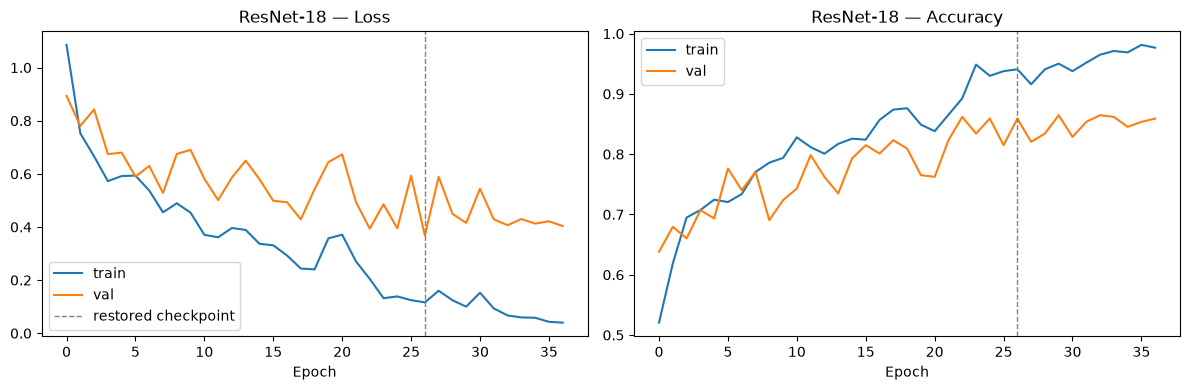

In [3]:
history_resnet18 = train_model(
    model_resnet18, train_loader, val_loader, optimizer_resnet18, scheduler_resnet18,
    criterion_resnet18, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-18",
)
plot_training_curves(history_resnet18, "ResNet-18")

## Evaluate on the test set

[ResNet-18] Test accuracy: 0.842


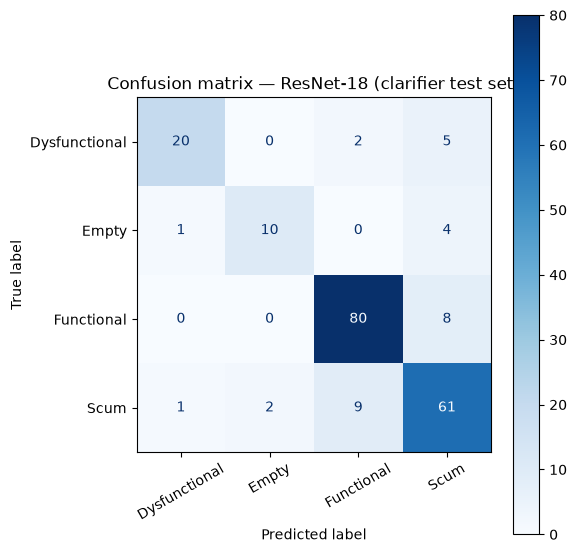

               precision    recall  f1-score   support

Dysfunctional      0.909     0.741     0.816        27
        Empty      0.833     0.667     0.741        15
   Functional      0.879     0.909     0.894        88
         Scum      0.782     0.836     0.808        73

     accuracy                          0.842       203
    macro avg      0.851     0.788     0.815       203
 weighted avg      0.845     0.842     0.841       203



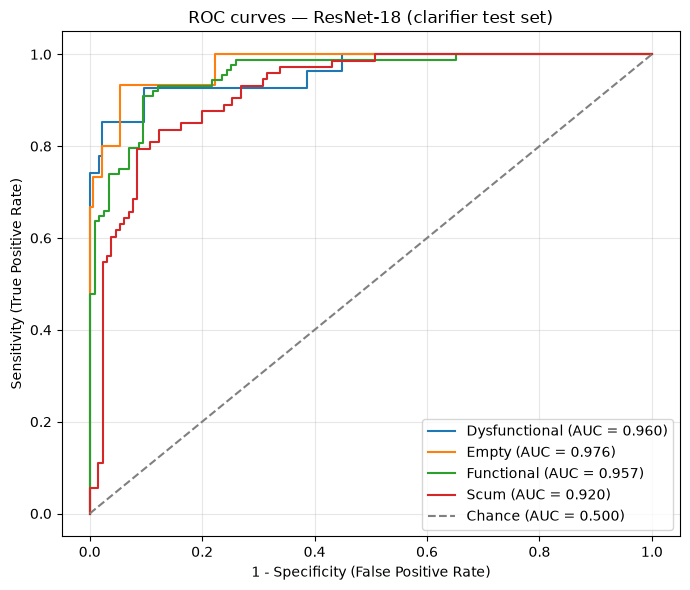

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.960
  Empty          : 0.976
  Functional     : 0.957
  Scum           : 0.920

Mean AUC: 0.953


(np.float64(0.8423645320197044),
 {'Dysfunctional': 0.9595959595959596,
  'Empty': 0.9762411347517731,
  'Functional': 0.9570158102766799,
  'Scum': 0.9198103266596417})

In [4]:
evaluate_and_record(
    model_resnet18, test_loader, "ResNet-18", history_resnet18,
    img_size=IMG_TARGET_SIZE, hidden_layers=0, neurons=None,
)

## Save results + model weights to disk

This is the step the results notebook depends on — it pickles the metrics/history and saves the model state dict so nothing needs to be kept in memory or re-trained.

In [5]:
save_result("ResNet-18", "resnet18")

Saved results to ../results/results_resnet18.pkl
Saved model weights to ../models/clarifier_resnet18_cnn.pt
